In [3]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [4]:
import sys
# mac_home_module_path = '/Users/martinploschner/OneDrive - The University of Queensland/Coding/python_scripts/MODULES/'
# sys.path.insert(1, mac_home_module_path)
win_home_module_path = r'C:\\LAB\\Coding\\Python\\MODULES'
sys.path.insert(1, win_home_module_path)

from scipy.interpolate import UnivariateSpline
from scipy import interpolate
import pickle
import os

[Text(0.5, 0, 'gray level'), Text(0, 0.5, 'power [dBm]')]

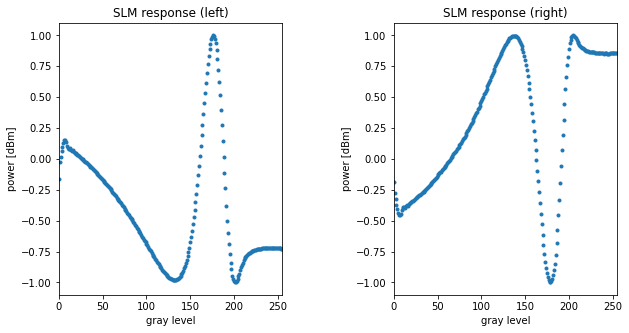

In [5]:
cwd = os.getcwd()
PIK1 = os.path.join(cwd,'results','2020_08_28_15_31_58_Meadowlark_1565nm_left_side_piston.pkl')
PIK2 = os.path.join(cwd,'results','2020_08_28_15_26_37_Meadowlark_1565nm_right_side_piston.pkl')

# Mesured in dBm, processing should be in W. Use 10^[(power in dBm)/(10 dBm)] to convert

with open(PIK1, "rb") as f:
    PIK1_data = pickle.load(f)

with open(PIK2, "rb") as f:
    PIK2_data = pickle.load(f)
    
l1 = np.asarray(PIK1_data['level'])
p1 = np.asarray(PIK1_data['measured_power'])
p1[-1] = p1[-2] # The last measured point is really weird and not really used later on, substituing with closest value that makes sense
p1 = 10**(p1/10)
p1_offset = (p1.max() - p1.min())/2 + p1.min()
p1 = p1 - p1_offset
p1 = -p1/np.abs(p1).max()


l2 = np.asarray(PIK2_data['level'])
p2 = np.asarray(PIK2_data['measured_power'])
p2[-1] = p2[-2] # The last measured point is really weird and not really used later on, substituing with closest value that makes sense
p2 = 10**(p2/10)
p2_offset = (p2.max() - p2.min())/2 + p2.min()
p2 = p2 - p2_offset
p2 = -p2/np.abs(p2).max()


fig,ax = plt.subplots(1,2,figsize=(10,5))
plt.subplots_adjust(wspace = 0.5)

ax[0].plot(l1,p1,'.')
ax[0].set_xlim(0,255)
ax[0].set_title('SLM response (left)')
ax[0].set(xlabel = 'gray level', ylabel = r'power [dBm]')

ax[1].plot(l2,p2,'.')
ax[1].set_xlim(0,255)
ax[1].set_title('SLM response (right)')
ax[1].set(xlabel = 'gray level', ylabel = r'power [dBm]')

# Getting the argument (Arc cos (x))

[Text(0.5, 0, 'gray level'), Text(0, 0.5, 'arg(rad)')]

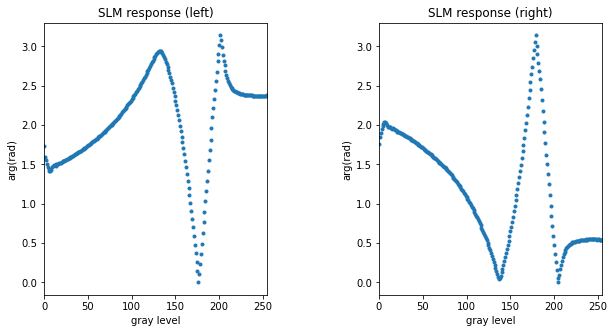

In [8]:
l = l1
phl = arccos(p1)
phr = arccos(p2)

fig,ax = plt.subplots(1,2,figsize=(10,5))
plt.subplots_adjust(wspace = 0.5)

ax[0].plot(l,phl,'.')
ax[0].set_xlim(0,255)
ax[0].set_title('SLM response (left)')
ax[0].set(xlabel = 'gray level', ylabel = r'arg(rad)')

ax[1].plot(l,phr,'.')
ax[1].set_xlim(0,255)
ax[1].set_title('SLM response (right)')
ax[1].set(xlabel = 'gray level', ylabel = r'arg(rad)')

# Unwrap the phase --> pick one of the two pistoning measurements

Whole SLM phase drive =  8.759926108388514 rad,  1.3941855412697821  cycles


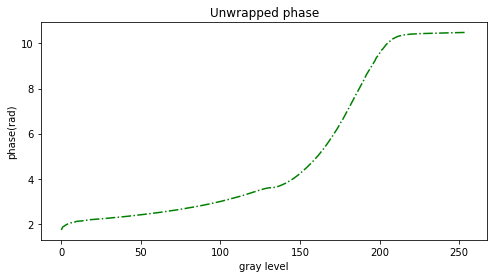

In [9]:
uwph = zeros(phl.shape[0]) #my fresh new unwrapped phase vector
Aph = phl[1::]-phl[0:-1] #Get the gradient --> using left side
uwph[0] = phl[0] #Assign first element
for idx,step in enumerate(abs(Aph)):
    uwph[idx+1] = uwph[idx] + step
    
fig,ax = plt.subplots(1,1,figsize=(8,4))
ax.plot(l,uwph,'-.',color='green')
ax.set_title('Unwrapped phase')
ax.set(xlabel = 'gray level', ylabel = r'phase(rad)')
print('Whole SLM phase drive = ', uwph.max() - uwph.min(), 'rad, ', (uwph.max() - uwph.min())/(2*pi), ' cycles')

# Translating unwraped phase to SLM language (Voltage levels!!)

Array position Start:  140 Nearest value:  0.5999204682251325
Array position Stop:  206 Nearest value:  1.6022601299221493
min Voltage level:  1123.8431372549019 --> 0pi
max Voltage level:  1653.6549019607844  --> 2pi


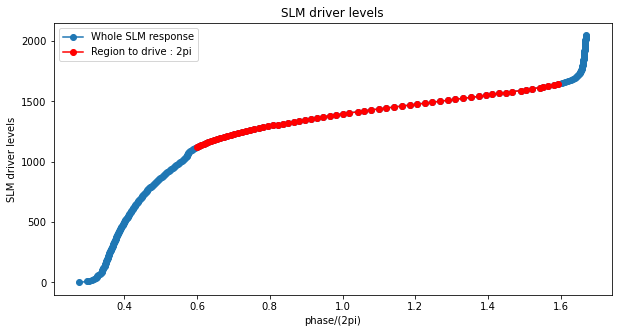

In [10]:
# SLM has 2047 levels (11 bits)
# Display just 256 levels: default lineal LUT maps 0 to 0 up 2047 to 256 using whole voltage range of the SLM driver (256 values between 0 and 2047)
#     --> NOW we just want to map all those 256 levels in a region that give us a phsae shift between 0 and 2pi
voltageDriver = linspace(0,2047,256)
#Normalize ph to multiples of 2pi
uwph_w = uwph / (2*pi)
fig,ax = plt.subplots(1,1,figsize=(10,5))
plot(uwph_w,voltageDriver,'-o',label='Whole SLM response')
ax.set_title('SLM driver levels')
ax.set(xlabel = r'phase/(2pi)', ylabel = 'SLM driver levels')
#Selet region : from 0.6 t0 1.6
region = zeros(voltageDriver.shape[0])
regin_startValue = 0.6
regin_stopValue = 1.6 
diff_start = abs(uwph_w - regin_startValue)
diff_stop = abs(uwph_w - regin_stopValue)
value_start = diff_start.argmin()
value_stop = diff_stop.argmin()
print('Array position Start: ', value_start, 'Nearest value: ', uwph_w[value_start] )
print('Array position Stop: ', value_stop, 'Nearest value: ', uwph_w[value_stop] )
plot(uwph_w[value_start:value_stop],voltageDriver[value_start:value_stop],'-o',color='red',label='Region to drive : 2pi')
legend()
print('min Voltage level: ', voltageDriver[value_start], '--> 0pi' )
print('max Voltage level: ', voltageDriver[value_stop], ' --> 2pi')



# Fit experimental data to a spline( ph(V) ) then invert ( V(ph) )

[Text(0.5, 0, 'Voltage level'), Text(0, 0.5, 'cycles')]

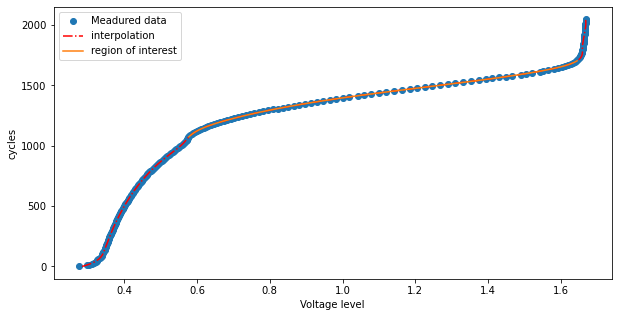

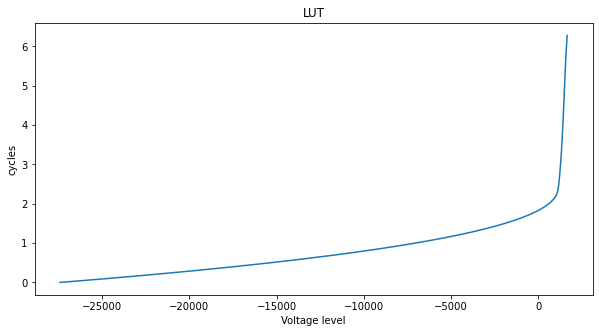

In [12]:
#Fit to the spline --> Phase function that depend on the voltage
spl = UnivariateSpline(voltageDriver,uwph_w, k = 3)
spl.set_smoothing_factor(0.0005)
phase = spl(voltageDriver)

fig,ax = plt.subplots(1,1,figsize=(10,5))
plot(uwph_w,voltageDriver,'o',label = 'Meadured data')
plot(phase,voltageDriver,'-.',color = 'red',label = 'interpolation')
ax.set(xlabel = 'Voltage level', ylabel = 'cycles')
legend()

#Let's avoid to inverd weird regions --> invert just region of interest + some more samples --> Voltage function that depend on ph
voltage_region = linspace(voltageDriver[value_start]-50,voltageDriver[value_stop]+50,256) #Select some region around
phase_region = spl(voltage_region)#Get the phase
spl_vol = UnivariateSpline(phase_region,voltage_region, k = 3) #Fit to the inverted spline
spl_vol.set_smoothing_factor(0)
plot(phase_region,spl_vol(phase_region),label='region of interest') #What I am gonna to invert
legend()

#NOW --> Select the 0 to 2pi region in this case 0.6 to 1.6
phase_range = linspace(0,1.6,256) #Accurate region to produce 0 to 2pi shift
LUT_voltage = around(spl_vol(phase_range)).astype(int) #THE LUT VOLTAGES!!!!!
fig,ax = plt.subplots(1,1,figsize=(10,5))

#PLOT THE ACCURATE SLM REGION TO PRODUCE 2pi shift
#Just for visual pourposes, scale the region in this case 0.6 = 0 / 1.6 = 2pi
phase_range_norm = phase_range - phase_range.min()
phase_range_norm = phase_range_norm/phase_range_norm.max() *2*pi
plot(LUT_voltage,phase_range_norm)
title('LUT')
ax.set(xlabel = 'Voltage level', ylabel = 'cycles')





# Check voltages if you want: if you get linear steps, probably you are doing something wrong or SLM is soooooo GOOD!

[1123 1129 1135 1140 1146 1151 1155 1160 1164 1169 1173 1177 1181 1184
 1188 1192 1195 1199 1202 1206 1209 1212 1215 1219 1222 1225 1228 1231
 1234 1237 1240 1243 1246 1249 1251 1254 1257 1260 1262 1265 1268 1270
 1273 1275 1278 1281 1283 1285 1288 1290 1293 1295 1298 1300 1302 1304
 1307 1309 1311 1314 1316 1318 1320 1322 1324 1327 1329 1331 1333 1335
 1337 1339 1341 1343 1345 1347 1349 1351 1353 1355 1357 1359 1361 1363
 1364 1366 1368 1370 1372 1374 1376 1377 1379 1381 1383 1384 1386 1388
 1390 1391 1393 1395 1397 1398 1400 1402 1403 1405 1407 1408 1410 1412
 1413 1415 1416 1418 1420 1421 1423 1424 1426 1427 1429 1430 1432 1434
 1435 1437 1438 1440 1441 1443 1444 1446 1447 1449 1450 1452 1453 1455
 1456 1458 1459 1461 1462 1464 1465 1466 1468 1469 1471 1472 1474 1475
 1477 1478 1480 1481 1483 1484 1485 1487 1488 1490 1491 1493 1494 1496
 1497 1499 1500 1502 1503 1505 1506 1507 1509 1510 1512 1513 1515 1516
 1518 1519 1521 1522 1524 1525 1527 1528 1530 1531 1533 1534 1536 1538
 1539 

(256,)

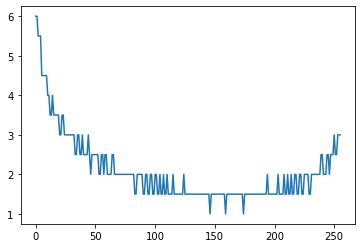

In [302]:
plot(gradient(LUT_voltage))
print(LUT_voltage)
LUT_voltage.shape

# Save the LUT!!

In [281]:
np.savetxt('SLM_001_NOAR_1565nm.blt', np.transpose(LUT_voltage), fmt='%.18g')

In [13]:
LUT_voltage = ones(256) * 1423
np.savetxt('SLM_002_testLUT.blt', np.transpose(LUT_voltage), fmt='%.18g')